In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

In [ ]:
base_dir = "/content/drive/MyDrive/EXPO"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 256
batch_size = 8

# ✅ Correct full paths
train_dir = "/content/drive/MyDrive/EXPO/train"
val_dir   = "/content/drive/MyDrive/EXPO/valid"

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Train Generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

# Validation Generator
val_generator = val_datagen.flow_from_directory(
    val_dir,   # ✅ Corrected path
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

print("Classes:", train_generator.class_indices)

Found 14970 images belonging to 2 classes.
Found 6304 images belonging to 3 classes.
Classes: {'nowildfire': 0, 'wildfire': 1}


In [ ]:
import shutil
import os

for folder in [train_dir, val_dir]:
    checkpoint_path = os.path.join(folder, ".ipynb_checkpoints")
    if os.path.exists(checkpoint_path):
        shutil.rmtree(checkpoint_path)
        print("Removed:", checkpoint_path)

Removed: /content/drive/MyDrive/EXPO/valid/.ipynb_checkpoints


In [ ]:
print(train_generator.class_indices)
print("Training samples:", train_generator.samples)

{'nowildfire': 0, 'wildfire': 1}
Training samples: 14970


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 23370 images belonging to 4 classes.
Found 5842 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 128, 384)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128, 128)       │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214,276 (837.02 KB)

 Trainable params: 214,276 (837.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 1756s 2s/step - accuracy: 0.5060 - loss: 1.2001 - val_accuracy: 0.5125 - val_loss: 1.1633
Epoch 2/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 370s 505ms/step - accuracy: 0.5175 - loss: 1.1827 - val_accuracy: 0.5125 - val_loss: 1.1665
Epoch 3/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 362s 495ms/step - accuracy: 0.5140 - loss: 1.1767 - val_accuracy: 0.5125 - val_loss: 1.1605
Epoch 4/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 364s 498ms/step - accuracy: 0.5146 - loss: 1.1765 - val_accuracy: 0.5125 - val_loss: 1.1623
Epoch 5/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 358s 490ms/step - accuracy: 0.5081 - loss: 1.1786 - val_accuracy: 0.5125 - val_loss: 1.1435
Epoch 6/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 358s 490ms/step - accuracy: 0.5124 - loss: 1.1749 - val_accuracy: 0.5125 - val_loss: 1.1742
Epoch 7/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 351s 480ms/step - accuracy: 0.5112 - loss: 1.1725 - val_accuracy: 0.5125 - val_loss: 1.1544
Epoch 8/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 353s 483ms/step - accuracy: 0.5103 - l

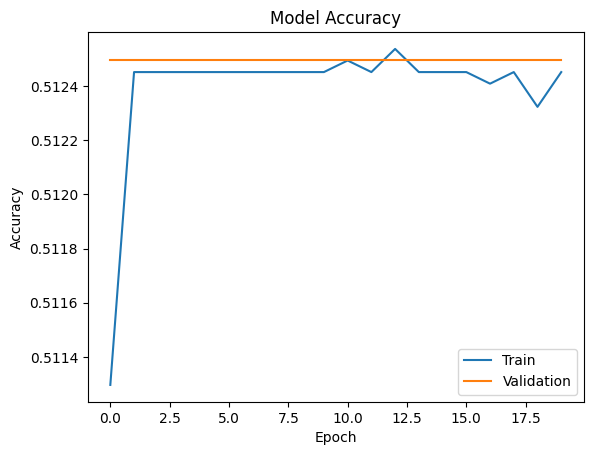

183/183 ━━━━━━━━━━━━━━━━━━━━ 49s 261ms/step


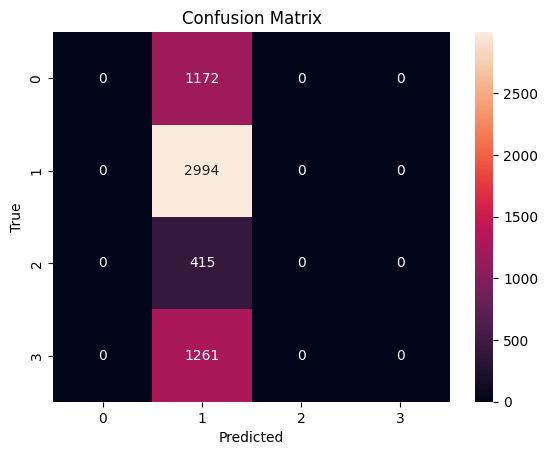


Classification Report:

              precision    recall  f1-score   support

        test       0.00      0.00      0.00      1172
       train       0.51      1.00      0.68      2994
 train_small       0.00      0.00      0.00       415
       valid       0.00      0.00      0.00      1261

    accuracy                           0.51      5842
   macro avg       0.13      0.25      0.17      5842
weighted avg       0.26      0.51      0.35      5842



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [2]:
# ===============================
# 1. Mount Google Drive
# ===============================
from google.colab import drive
drive.mount('/content/drive')

# ===============================
# 2. Imports
# ===============================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Dropout, Flatten, TimeDistributed
from tensorflow.keras.optimizers import Adam

# ===============================
# 3. Dataset Path
# ===============================
data_path = "/content/drive/MyDrive/EXPO"

IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 20

# ===============================
# 4. Data Generator
# ===============================
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

num_classes = train_generator.num_classes

# ===============================
# 5. Build LSTM + RNN Model
# ===============================
model = Sequential()

# Reshape image for RNN input (sequence format)
model.add(TimeDistributed(Flatten(), input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(SimpleRNN(128, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(128))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

# ===============================
# 6. Compile Model
# ===============================
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ===============================
# 7. Train Model
# ===============================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

# ===============================
# 8. Accuracy Plot
# ===============================
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# ===============================
# 9. Confusion Matrix
# ===============================
val_generator.reset()
pred = model.predict(val_generator)
pred_classes = np.argmax(pred, axis=1)
true_classes = val_generator.classes

cm = confusion_matrix(true_classes, pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("\nClassification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=list(train_generator.class_indices.keys())))

In [4]:
# Mount Drive (if not mounted)
from google.colab import drive
drive.mount('/content/drive')

# Save the trained model
model.save("/content/drive/MyDrive/lstm_rnn_model.h5")

print("✅ Model saved successfully as lstm_rnn_model.h5")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model saved successfully as lstm_rnn_model.h5


In [5]:
import os

print(os.path.exists("/content/drive/MyDrive/lstm_rnn_model.h5"))

True


In [6]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'TA05_Agriculture.pptx', 'ecommerce website', 'URH2284321.pdf', 'Classroom', 'Screenshot_2023_1207_232455.png', 'Great Learning  Academy. Certificate  Vasu.png', 'Interview project. Vikas .mp4', 'IMG_20231213_190453.jpg', '1646 2.pdf', 'Screenshot 2024-04-12 194341.png', 'vasu img (1).jpg', 'vasu img.jpg', 'OS ASSignment 1 & 2.pdf', 'OS   CERTIFICATE.pdf', 'CISCO  Saylor  Certificte.pdf', 'NEXT24TECH  Offer Letter  jpg.png', 'HCI -Certificate  Frondend Development (2).pdf', 'HCI -Certificate  Frondend Development (1).pdf', 'HCI -Certificate  Frondend Development.pdf', 'main.js', 'CNN Cisco.pdf', '2303A51618.pdf', 'VASU_2303A51618_306.java', 'PB_306.docx', 'codespark-SIH2024_IDEA_Presentation_Format PDF.pdf', 'iris.zip', 'iris.data', '2303A51618_LAB_EXAM.pdf', '2303A51618_PDF.pdf', '2303A51284_18_B17.ipynb', '2303A51618_LAB_EXAM.gdoc', '2303A51618_25.ipynb - Colab.html', '2303A51618_25.ipynb', 'lab5.ipynb', 'lab5-1.pdf', 'lab5 -2.pdf', 'Problem_Statements(Hackathon).